In [ ]:
#i mports & config

import polars as pl
import datetime as dt
import math
import os
import sf_quant as sf

START = dt.date(2019, 1, 1)
END   = dt.date(2024, 12, 31)

BASE_DATA_DIR = "/home/nchasem/sf-quant-labs/research/data"
EDGAR_PATH    = os.path.join(BASE_DATA_DIR, "institutional_holdings.csv")

ASSET_COLS = [
    "date",
    "barrid",
    "ticker",
    "cusip",
    "market_cap",
    "price",
    "return",         
    "in_universe",
    "russell_1000",
    "russell_2000",
]

In [ ]:
# load daily assets from sf_quant

df = sf.data.load_assets(
    start=START,
    end=END,
    in_universe=False,
    columns=ASSET_COLS,
)

# type-cast and build cusip8, daily decimal return
df = (
    df
    .with_columns([
        pl.col("date").cast(pl.Date),
        pl.col("barrid").cast(pl.Utf8, strict=False),
        pl.col("ticker").cast(pl.Utf8, strict=False),
        pl.col("cusip").cast(pl.Utf8, strict=False),
        pl.col("market_cap").cast(pl.Float64, strict=False),
        pl.col("price").cast(pl.Float64, strict=False),
        pl.col("return").cast(pl.Float64, strict=False),  # percent
    ])
    .with_columns([
        # first 8 chars of CUSIP for matching
        pl.when(pl.col("cusip").is_not_null())
          .then(pl.col("cusip").str.slice(0, 8))
          .otherwise(None)
          .alias("cusip8"),
        # daily decimal return
        (pl.col("return") / 100.0).alias("ret_d"),
    ])
)

print("Daily assets shape:", df.shape)
print(df.head())

Daily assets shape: (31015232, 12)
shape: (5, 12)
┌────────────┬─────────┬────────┬───────────┬───┬─────────────┬─────────────┬──────────┬───────────┐
│ date       ┆ barrid  ┆ ticker ┆ cusip     ┆ … ┆ russell_100 ┆ russell_200 ┆ cusip8   ┆ ret_d     │
│ ---        ┆ ---     ┆ ---    ┆ ---       ┆   ┆ 0           ┆ 0           ┆ ---      ┆ ---       │
│ date       ┆ str     ┆ str    ┆ str       ┆   ┆ ---         ┆ ---         ┆ str      ┆ f64       │
│            ┆         ┆        ┆           ┆   ┆ bool        ┆ bool        ┆          ┆           │
╞════════════╪═════════╪════════╪═══════════╪═══╪═════════════╪═════════════╪══════════╪═══════════╡
│ 2022-12-29 ┆ ARGA1B1 ┆ null   ┆ P0R67N384 ┆ … ┆ null        ┆ null        ┆ P0R67N38 ┆ 0.025204  │
│ 2022-12-30 ┆ ARGA1B1 ┆ null   ┆ P0R67N384 ┆ … ┆ null        ┆ null        ┆ P0R67N38 ┆ -0.015615 │
│ 2023-01-03 ┆ ARGA1B1 ┆ null   ┆ P0R67N384 ┆ … ┆ null        ┆ null        ┆ P0R67N38 ┆ -0.020645 │
│ 2023-01-04 ┆ ARGA1B1 ┆ null   ┆ P0R67N3

In [ ]:
# build quarterly panel from daily data

# sanity caps on daily and quarterly returns (in decimal units, not percent)
DAILY_RET_ABS_CAP_DEC = 2.0    # +/- 200% per day
QTR_RET_ABS_CAP_DEC   = 5.0    # +/- 500% per quarter

df_q = (
    df
    .filter(
        pl.col("ret_d").is_not_null()
        & (pl.col("ret_d").abs() < DAILY_RET_ABS_CAP_DEC)
        & pl.col("market_cap").is_not_null()
        & (pl.col("market_cap") > 0)
        & pl.col("price").is_not_null()
        & (pl.col("price") > 0)
        & pl.col("cusip8").is_not_null()
    )
    .with_columns([
        pl.col("date").dt.year().alias("year"),
        pl.col("date").dt.quarter().alias("quarter"),
    ])
    .with_columns(
        pl.when(pl.col("quarter") == 1).then(pl.date(pl.col("year"), 3, 31))
        .when(pl.col("quarter") == 2).then(pl.date(pl.col("year"), 6, 30))
        .when(pl.col("quarter") == 3).then(pl.date(pl.col("year"), 9, 30))
        .otherwise(pl.date(pl.col("year"), 12, 31))
        .alias("qdate")
    )
)

crsp_q = (
    df_q
    .sort(["barrid", "date"])
    .group_by(["barrid", "cusip8", "year", "quarter", "qdate"])
    .agg([
        pl.col("date").max().alias("last_obs_date"),

        pl.col("ticker").last().alias("ticker"),
        pl.col("market_cap").last().alias("market_cap"),
        pl.col("price").last().alias("price"),

        pl.col("in_universe").any().alias("in_universe"),
        pl.col("russell_1000").any().alias("russell_1000"),
        pl.col("russell_2000").any().alias("russell_2000"),

        # quarterly compounded return from daily decimal returns
        (pl.col("ret_d") + 1.0).log().sum().exp().sub(1.0).alias("ret_q"),
    ])
    .filter(pl.col("ret_q").is_not_null())
    .filter(pl.col("ret_q").abs() <= QTR_RET_ABS_CAP_DEC)
    .sort(["barrid", "qdate"])
)

print("Quarterly CRSP-like panel shape:", crsp_q.shape)
print(
    crsp_q
    .select(["barrid", "cusip8", "qdate", "ret_q", "market_cap", "price"])
    .head()
)

Quarterly CRSP-like panel shape: (471724, 13)
shape: (5, 6)
┌─────────┬──────────┬────────────┬──────────┬────────────┬─────────┐
│ barrid  ┆ cusip8   ┆ qdate      ┆ ret_q    ┆ market_cap ┆ price   │
│ ---     ┆ ---      ┆ ---        ┆ ---      ┆ ---        ┆ ---     │
│ str     ┆ str      ┆ date       ┆ f64      ┆ f64        ┆ f64     │
╞═════════╪══════════╪════════════╪══════════╪════════════╪═════════╡
│ ARGA1B1 ┆ P0R67N38 ┆ 2022-12-31 ┆ 0.009195 ┆ 4.0262e12  ┆ 2963.0  │
│ ARGA1B1 ┆ P0R67N38 ┆ 2023-03-31 ┆ 0.444963 ┆ 6.0520e12  ┆ 4560.0  │
│ ARGA1B1 ┆ P0R67N38 ┆ 2023-06-30 ┆ 0.271737 ┆ 8.0746e12  ┆ 6084.0  │
│ ARGA1B1 ┆ P0R67N38 ┆ 2023-09-30 ┆ 0.200093 ┆ 9.9801e12  ┆ 7292.0  │
│ ARGA1B1 ┆ P0R67N79 ┆ 2023-12-31 ┆ 0.583643 ┆ 2.3111e13  ┆ 16600.0 │
└─────────┴──────────┴────────────┴──────────┴────────────┴─────────┘


In [ ]:
# load EDGAR institutional holdings and build quarterly IO panel

HOLDINGS_PATH = "/home/nchasem/sf-quant-labs/research/data/institutional_holdings.csv"

io_raw = pl.read_csv(HOLDINGS_PATH)

print("Raw EDGAR holdings columns:", io_raw.columns)
print(io_raw.head())

io_q = (
    io_raw
    .with_columns([
        pl.col("CUSIP").cast(pl.Utf8, strict=False).str.strip_chars().alias("cusip"),
        pl.col("CUSIP").cast(pl.Utf8, strict=False).str.strip_chars().str.slice(0, 8).alias("cusip8"),
        # fdate is quarter-end; parse to Date
        pl.col("fdate").cast(pl.Utf8).str.strip_chars().str.strptime(pl.Date, strict=False).alias("qdate"),
        pl.col("SSHPRNAMT").cast(pl.Float64, strict=False).alias("shares_inst"),
        pl.col("VALUE").cast(pl.Float64, strict=False).alias("value_inst"),
    ])
    .filter(
        pl.col("cusip8").is_not_null()
        & pl.col("qdate").is_not_null()
        & pl.col("shares_inst").is_not_null()
        & (pl.col("shares_inst") > 0)
    )
    .group_by(["cusip8", "qdate"])
    .agg([
        pl.col("shares_inst").sum().alias("inst_shares"),
        pl.col("value_inst").sum().alias("inst_value"),
    ])
    .sort(["cusip8", "qdate"])
)

print("Quarterly EDGAR IO panel shape:", io_q.shape)
print(io_q.head())

Raw EDGAR holdings columns: ['CUSIP', 'fdate', 'SSHPRNAMT', 'VALUE']
shape: (5, 4)
┌───────────┬────────────┬───────────┬───────┐
│ CUSIP     ┆ fdate      ┆ SSHPRNAMT ┆ VALUE │
│ ---       ┆ ---        ┆ ---       ┆ ---   │
│ str       ┆ str        ┆ i64       ┆ i64   │
╞═══════════╪════════════╪═══════════╪═══════╡
│ 00032Q104 ┆ 2021-12-31 ┆ 165655    ┆ 4865  │
│ 00032Q104 ┆ 2022-03-31 ┆ 128522    ┆ 3104  │
│ 00032Q104 ┆ 2022-06-30 ┆ 351053    ┆ 5958  │
│ 00032Q104 ┆ 2022-09-30 ┆ 715566    ┆ 8816  │
│ 00032Q104 ┆ 2022-12-31 ┆ 811051    ┆ 11461 │
└───────────┴────────────┴───────────┴───────┘
Quarterly EDGAR IO panel shape: (177665, 4)
shape: (5, 4)
┌──────────┬────────────┬─────────────┬────────────┐
│ cusip8   ┆ qdate      ┆ inst_shares ┆ inst_value │
│ ---      ┆ ---        ┆ ---         ┆ ---        │
│ str      ┆ date       ┆ f64         ┆ f64        │
╞══════════╪════════════╪═════════════╪════════════╡
│ 00032Q10 ┆ 2021-12-31 ┆ 165655.0    ┆ 4865.0     │
│ 00032Q10 ┆ 2022-03-31 

In [ ]:
# Merge CRSP quarterly panel with EDGAR IO and compute IO%

# Merge on cusip8 + qdate
crsp_io = (
    crsp_q
    .join(
        io_q,
        on=["cusip8", "qdate"],
        how="left",
    )
)

print("After merge shape:", crsp_io.shape)
print(crsp_io.select(["barrid", "cusip8", "qdate", "ret_q", "market_cap", "price", "inst_shares"]).head(10))

# Estimate shrout from market cap and price
crsp_io = (
    crsp_io
    .with_columns(
        [
            # guard against zeros / nulls
            pl.when(
                (pl.col("market_cap").is_not_null())
                & (pl.col("price").is_not_null())
                & (pl.col("price") > 0)
            )
            .then(pl.col("market_cap") / pl.col("price"))
            .otherwise(None)
            .alias("shares_out_est")
        ]
    )
)

# Compute IO % = institutional shares / shares outstanding
crsp_io = (
    crsp_io
    .with_columns(
        [
            pl.when(
                (pl.col("inst_shares").is_not_null())
                & (pl.col("shares_out_est").is_not_null())
                & (pl.col("shares_out_est") > 0)
            )
            .then(pl.col("inst_shares") / pl.col("shares_out_est"))
            .otherwise(None)
            .alias("io_pct_raw")
        ]
    )
    # Clip to a sane range, in decimal units
    .with_columns(
        pl.when(pl.col("io_pct_raw").is_not_null())
        .then(pl.col("io_pct_raw").clip(0.0, 1.2))
        .otherwise(None)
        .alias("io_pct")
    )
)

print(
    "IO coverage (non-null io_pct):",
    crsp_io.select(pl.col("io_pct").is_not_null().mean().alias("coverage")).item()
)

print(
    crsp_io
    .select(
        [
            "barrid",
            "cusip8",
            "qdate",
            "ret_q",
            "market_cap",
            "price",
            "inst_shares",
            "shares_out_est",
            "io_pct",
        ]
    )
    .head(10)
)

After merge shape: (471724, 15)
shape: (10, 7)
┌─────────┬──────────┬────────────┬───────────┬────────────┬─────────┬─────────────┐
│ barrid  ┆ cusip8   ┆ qdate      ┆ ret_q     ┆ market_cap ┆ price   ┆ inst_shares │
│ ---     ┆ ---      ┆ ---        ┆ ---       ┆ ---        ┆ ---     ┆ ---         │
│ str     ┆ str      ┆ date       ┆ f64       ┆ f64        ┆ f64     ┆ f64         │
╞═════════╪══════════╪════════════╪═══════════╪════════════╪═════════╪═════════════╡
│ ARGA1B1 ┆ P0R67N38 ┆ 2022-12-31 ┆ 0.009195  ┆ 4.0262e12  ┆ 2963.0  ┆ null        │
│ ARGA1B1 ┆ P0R67N38 ┆ 2023-03-31 ┆ 0.444963  ┆ 6.0520e12  ┆ 4560.0  ┆ null        │
│ ARGA1B1 ┆ P0R67N38 ┆ 2023-06-30 ┆ 0.271737  ┆ 8.0746e12  ┆ 6084.0  ┆ null        │
│ ARGA1B1 ┆ P0R67N38 ┆ 2023-09-30 ┆ 0.200093  ┆ 9.9801e12  ┆ 7292.0  ┆ null        │
│ ARGA1B1 ┆ P0R67N79 ┆ 2023-12-31 ┆ 0.583643  ┆ 2.3111e13  ┆ 16600.0 ┆ null        │
│ ARGA1B1 ┆ P0R67N17 ┆ 2023-12-31 ┆ -0.003609 ┆ 1.3839e13  ┆ 9940.0  ┆ null        │
│ ARGA1B1 ┆ P0R67N

In [ ]:
# build final quarterly panel with forward return and IO signal

final_panel = (
    crsp_io
    .with_columns([
        pl.col("ret_q").shift(-1).over("barrid").alias("ret_fwd"),
    ])
    .filter(pl.col("ret_fwd").is_not_null())
)

print("final_panel shape:", final_panel.shape)

# Proper IO coverage check
io_cov_final = (
    final_panel
    .select(pl.col("io_pct").is_not_null().mean())
    .item()
)

print("IO coverage in final_panel:", io_cov_final)

print(
    final_panel
    .select([
        "barrid",
        "cusip8",
        "qdate",
        "ret_q",
        "ret_fwd",
        "market_cap",
        "price",
        "inst_shares",
        "shares_out_est",
        "io_pct",       
        "in_universe",
    ])
    .head(10)
)

FINAL_PANEL_PATH = "/home/nchasem/sf-quant-labs/research/data/final_panel_io_quarterly.parquet"
final_panel.write_parquet(FINAL_PANEL_PATH)

print("Saved final panel to:", FINAL_PANEL_PATH)

final_panel shape: (445049, 19)
IO coverage in final_panel: 0.44007064390662604
shape: (10, 11)
┌─────────┬──────────┬────────────┬───────────┬───┬─────────────┬────────────┬────────┬────────────┐
│ barrid  ┆ cusip8   ┆ qdate      ┆ ret_q     ┆ … ┆ inst_shares ┆ shares_out ┆ io_pct ┆ in_univers │
│ ---     ┆ ---      ┆ ---        ┆ ---       ┆   ┆ ---         ┆ _est       ┆ ---    ┆ e          │
│ str     ┆ str      ┆ date       ┆ f64       ┆   ┆ f64         ┆ ---        ┆ f64    ┆ ---        │
│         ┆          ┆            ┆           ┆   ┆             ┆ f64        ┆        ┆ bool       │
╞═════════╪══════════╪════════════╪═══════════╪═══╪═════════════╪════════════╪════════╪════════════╡
│ ARGA1B1 ┆ P0R67N38 ┆ 2022-12-31 ┆ 0.009195  ┆ … ┆ null        ┆ 1.3588e9   ┆ null   ┆ false      │
│ ARGA1B1 ┆ P0R67N38 ┆ 2023-03-31 ┆ 0.444963  ┆ … ┆ null        ┆ 1.3272e9   ┆ null   ┆ false      │
│ ARGA1B1 ┆ P0R67N38 ┆ 2023-06-30 ┆ 0.271737  ┆ … ┆ null        ┆ 1.3272e9   ┆ null   ┆ false   

## Quintiles and Performance

In [ ]:
# choose IO column and convert to pandas

import pandas as pd
import numpy as np

# IO column name in final_panel
IO_COL = "io_pct"

# Start from final_panel (polars -> pandas)
panel_pd = final_panel.to_pandas()

# keep rows with valid IO and current-quarter return
panel_pd = panel_pd[
    panel_pd[IO_COL].notna()
    & panel_pd["ret_q"].notna()
].copy()

# restrict to in_universe
if "in_universe" in panel_pd.columns:
    panel_pd = panel_pd[panel_pd["in_universe"].fillna(False)].copy()

print(panel_pd[["barrid", "qdate", IO_COL, "ret_q"]].head())
print("Panel shape after filter:", panel_pd.shape)

         barrid      qdate    io_pct     ret_q
131352  USA06Z1 2021-06-30  0.000819  0.214562
131353  USA06Z1 2021-09-30  0.001202 -0.515586
131354  USA06Z1 2021-12-31  0.001022 -0.003302
131355  USA06Z1 2022-03-31  0.001587 -0.220197
131356  USA06Z1 2022-06-30  0.002756 -0.263273
Panel shape after filter: (59586, 19)


In [ ]:
# assign IO quintiles

def assign_quintiles(x, n=5):
    # x is the IO series for a given quarter
    return pd.qcut(x, n, labels=range(1, n + 1), duplicates="drop")

panel_pd["io_q"] = (
    panel_pd
    .groupby("qdate")[IO_COL]
    .transform(assign_quintiles)
)

# Some quarters may have <5 bins (duplicates='drop'); io_q will be NaN there.
panel_pd["io_q"] = panel_pd["io_q"].astype("float")  # keep numeric for later

print(panel_pd[["barrid", "qdate", IO_COL, "io_q"]].head())
print("Unique io_q:", panel_pd["io_q"].unique())

         barrid      qdate    io_pct  io_q
131352  USA06Z1 2021-06-30  0.000819   1.0
131353  USA06Z1 2021-09-30  0.001202   1.0
131354  USA06Z1 2021-12-31  0.001022   1.0
131355  USA06Z1 2022-03-31  0.001587   1.0
131356  USA06Z1 2022-06-30  0.002756   2.0
Unique io_q: [1. 2. 3. 4. 5.]


In [ ]:
# equal-weight portfolio returns and spread

# Drop rows where we couldn't assign a quintile
ports = panel_pd.dropna(subset=["io_q"]).copy()

# Equal-weight quarterly return per
port_ret = (
    ports
    .groupby(["qdate", "io_q"])["ret_q"]
    .mean()
    .rename("ret_q_ew")
    .reset_index()
)

print("port_ret head:")
print(port_ret.head())

# Pivot to wide
wide = port_ret.pivot(index="qdate", columns="io_q", values="ret_q_ew")

# Keep only dates where all 5 quintiles exist
needed_bins = [1.0, 2.0, 3.0, 4.0, 5.0]
wide = wide[needed_bins]
wide = wide.dropna(how="any")       # drop quarters with missing bins

# Name the columns
wide.columns = [f"Q{int(c)}" for c in wide.columns]

# Spread
wide["spread"] = wide["Q5"] - wide["Q1"]
# Drop unstable final quarter bc it only has 2 entries
wide = wide.iloc[:-1]

print("Wide portfolio returns head:")
print(wide.head())

port_ret head:
       qdate  io_q  ret_q_ew
0 2019-03-31   1.0  0.133357
1 2019-03-31   2.0  0.146393
2 2019-03-31   3.0  0.189691
3 2019-03-31   4.0  0.170537
4 2019-03-31   5.0  0.202103
Wide portfolio returns head:
                  Q1        Q2        Q3        Q4        Q5    spread
qdate                                                                 
2019-03-31  0.133357  0.146393  0.189691  0.170537  0.202103  0.068746
2019-06-30  0.008217  0.031085  0.007144  0.011978  0.033952  0.025735
2019-09-30  0.013504 -0.009273 -0.022794 -0.034085 -0.069096 -0.082600
2019-12-31  0.073144  0.095844  0.109909  0.096233  0.205101  0.131957
2020-03-31 -0.301587 -0.317363 -0.317072 -0.325031 -0.321144 -0.019557


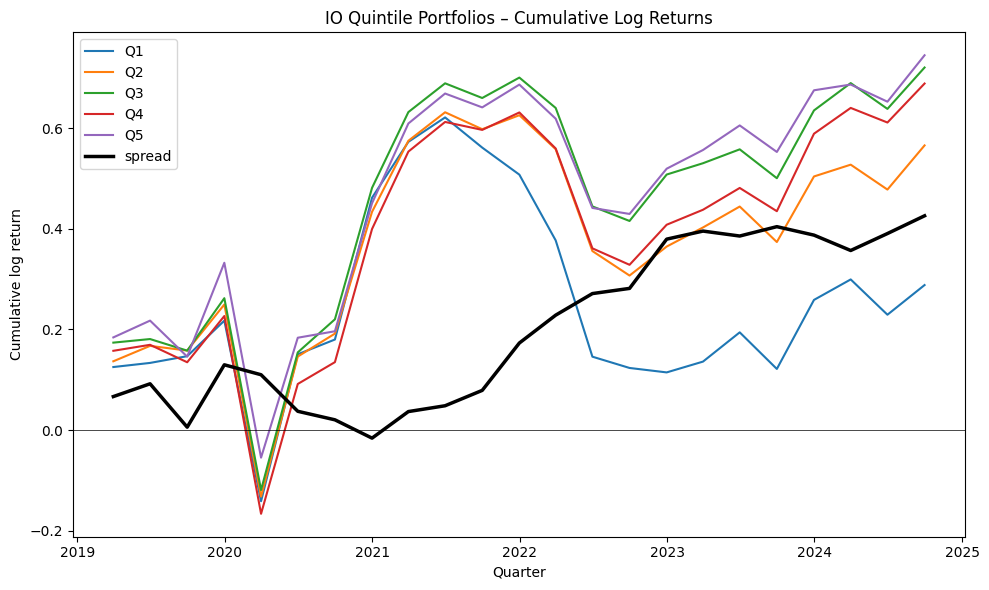

In [ ]:
# cumulative log returns time series

log_rets = np.log1p(wide)           # log(1 + R_q)
cum_log_rets = log_rets.cumsum()    # cumulative log-return

cum_log_rets.head()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for col in ["Q1","Q2","Q3","Q4","Q5"]:
    plt.plot(cum_log_rets.index, cum_log_rets[col], label=col)

# Plot spread as thick black line
plt.plot(
    cum_log_rets.index,
    cum_log_rets["spread"],
    color="black",
    linewidth=2.5,
    label="spread"
)

plt.axhline(0, color="black", linewidth=0.5)
plt.legend()
plt.title("IO Quintile Portfolios – Cumulative Log Returns")
plt.xlabel("Quarter")
plt.ylabel("Cumulative log return")
plt.tight_layout()
plt.show()

In [ ]:
# annualized return & Sharpe for each portfolio

stats = {}

for col in ["Q1","Q2","Q3","Q4","Q5","spread"]:
    r = wide[col].dropna()
    mean_q = r.mean()
    std_q  = r.std()
    n_obs  = r.shape[0]

    # Quarterly -> annual
    ann_ret = (1 + mean_q)**4 - 1          # compound from mean quarter
    ann_vol = std_q * np.sqrt(4.0)         # sqrt(4) scaling

    sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan

    stats[col] = {
        "mean_q":   mean_q,
        "std_q":    std_q,
        "n_obs":    n_obs,
        "ann_ret":  ann_ret,
        "ann_vol":  ann_vol,
        "sharpe":   sharpe,
    }

stats_df = pd.DataFrame(stats).T
stats_df

,mean_q,std_q,n_obs,ann_ret,ann_vol,sharpe
Q1,0.022222,0.142409,23.0,0.091893,0.284818,0.322639
Q2,0.033734,0.134334,23.0,0.141918,0.268668,0.528226
Q3,0.041078,0.138004,23.0,0.174717,0.276008,0.633015
Q4,0.039564,0.136577,23.0,0.167898,0.273155,0.614661
Q5,0.042212,0.137782,23.0,0.179842,0.275565,0.652632
spread,0.019990,0.052777,23.0,0.082390,0.105554,0.780552


In [33]:
# Quintile breakdowns
io_summary = (
    panel_pd
    .dropna(subset=["io_q"])
    .groupby("io_q")[IO_COL]
    .agg(["mean", "median", "std", "min", "max"])
    .sort_index()
)

io_summary

,mean,median,std,min,max
io_q,,,,,
1.0,0.008172,0.001574,0.018164,2.930715e-08,0.078846
2.0,0.017646,0.004573,0.032394,2.705529e-05,0.112066
3.0,0.025350,0.008360,0.042141,2.619210e-04,0.140021
4.0,0.035934,0.015488,0.051886,9.661639e-04,0.183430
5.0,0.065051,0.037525,0.067680,2.573701e-03,0.430498


In [34]:
import polars as pl

# Reset index so qdate becomes a column
spread_pd = wide[["spread"]].reset_index()

# Rename columns for sf_quant
spread_pd = spread_pd.rename(columns={
    "qdate": "date",
    "spread": "return"
})

# Convert to polars
spread_pl = pl.from_pandas(spread_pd)

spread_pl.head()

date,return
datetime[ms],f64
2019-03-31 00:00:00,0.068746
2019-06-30 00:00:00,0.025735
2019-09-30 00:00:00,-0.0826
2019-12-31 00:00:00,0.131957
2020-03-31 00:00:00,-0.019557


In [35]:
import pandas as pd
import statsmodels.api as sm
import pandas_datareader.data as web

# Pull monthly FF5 factors
ff5 = web.DataReader(
    "F-F_Research_Data_5_Factors_2x3",
    "famafrench"
)[0]

# Parse date index (YYYY-MM format)
ff5.index = pd.to_datetime(ff5.index.astype(str))

# Convert percent → decimal
ff5 = ff5 / 100.0

ff5.head()

/tmp/ipykernel_536249/3595041894.py:6: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff5 = web.DataReader(
/tmp/ipykernel_536249/3595041894.py:6: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff5 = web.DataReader(


,Mkt-RF,SMB,HML,RMW,CMA,RF
Date,,,,,,
2021-03-01,0.0316,-0.0084,0.0735,0.0635,0.0352,0.0
2021-04-01,0.0497,-0.0316,-0.0102,0.0243,-0.0272,0.0
2021-05-01,0.0029,0.0127,0.0704,0.0234,0.0301,0.0
2021-06-01,0.0273,-0.0030,-0.0786,-0.0214,-0.0093,0.0
2021-07-01,0.0134,-0.0455,-0.0179,0.0550,-0.0059,0.0


In [36]:
ff5_q = (
    ff5
    .resample("Q")
    .apply(lambda x: (1 + x).prod() - 1)
)

ff5_q.head()

spread_pd = wide[["spread"]].copy()
spread_pd.index = pd.to_datetime(spread_pd.index)

data5 = spread_pd.merge(
    ff5_q,
    left_index=True,
    right_index=True,
    how="inner"
)

print("Observations:", len(data5))
data5.head()

y = data5["spread"] - data5["RF"]

X = data5[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]]
X = sm.add_constant(X)

model5 = sm.OLS(y, X).fit()

model5.summary()

Observations: 15


/tmp/ipykernel_536249/686765539.py:3: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  .resample("Q")


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.806
Model:                            OLS   Adj. R-squared:                  0.699
Method:                 Least Squares   F-statistic:                     7.488
Date:                Mon, 02 Mar 2026   Prob (F-statistic):            0.00496
Time:                        16:09:02   Log-Likelihood:                 39.436
No. Observations:                  15   AIC:                            -66.87
Df Residuals:                       9   BIC:                            -62.62
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0163      0.008      1.988      0.078      -0.002       0.035
Mkt-RF        -0.0914      0.089     -1.029      0.330      -0.292       0.110
SMB            0.1971      0.206      0.956      0.364      -0.269       0.664
HML           -0.2286      0.187     -1.221      0.253      -0.652       0.195
RMW            0.4190      0.132      3.180      0.011       0.121       0.717
CMA            0.5210      0.203      2.569      0.030       0.062       0.980
==============================================================================
Omnibus:                        0.953   Durbin-Watson:                   2.405
Prob(Omnibus):                  0.621   Jarque-Bera (JB):                0.802
Skew:                          -0.306   Prob(JB):                        0.670
Kurtosis:                       2.048   Cond. No.                         47.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [37]:
results_ff5 = pd.DataFrame({
    "Coefficient": model5.params.round(4),
    "t-Statistic": model5.tvalues.round(4),
    "p-Value": model5.pvalues.round(4)
})

results_ff5.index = [
    "Alpha (Quarterly)",
    "Market Beta",
    "SMB Loading",
    "HML Loading",
    "RMW Loading",
    "CMA Loading"
]

alpha_q = model5.params["const"]
alpha_ann = (1 + alpha_q)**4 - 1

summary_ff5 = pd.DataFrame({
    "Metric": ["Alpha (Annualized)", "R-squared", "Observations"],
    "Value": [
        round(alpha_ann, 4),
        round(model5.rsquared, 4),
        int(model5.nobs)
    ]
})

results_ff5, summary_ff5

(                   Coefficient  t-Statistic  p-Value
 Alpha (Quarterly)       0.0163       1.9883   0.0780
 Market Beta            -0.0914      -1.0288   0.3304
 SMB Loading             0.1971       0.9559   0.3641
 HML Loading            -0.2286      -1.2212   0.2530
 RMW Loading             0.4190       3.1804   0.0112
 CMA Loading             0.5210       2.5693   0.0302,
                Metric    Value
 0  Alpha (Annualized)   0.0670
 1           R-squared   0.8062
 2        Observations  15.0000)

In [ ]:
# ---- Clean FF5 Table ----

import pandas as pd

# Factor table
ff5_table = pd.DataFrame({
    "Factor": [
        "Alpha (Quarterly)",
        "Market (Mkt-RF)",
        "Size (SMB)",
        "Value (HML)",
        "Profitability (RMW)",
        "Investment (CMA)"
    ],
    "Coefficient": [
        model5.params["const"],
        model5.params["Mkt-RF"],
        model5.params["SMB"],
        model5.params["HML"],
        model5.params["RMW"],
        model5.params["CMA"]
    ],
    "t-Statistic": [
        model5.tvalues["const"],
        model5.tvalues["Mkt-RF"],
        model5.tvalues["SMB"],
        model5.tvalues["HML"],
        model5.tvalues["RMW"],
        model5.tvalues["CMA"]
    ],
    "p-Value": [
        model5.pvalues["const"],
        model5.pvalues["Mkt-RF"],
        model5.pvalues["SMB"],
        model5.pvalues["HML"],
        model5.pvalues["RMW"],
        model5.pvalues["CMA"]
    ]
})

# Round
ff5_table = ff5_table.round(4)

# Annualized alpha
alpha_q = model5.params["const"]
alpha_ann = (1 + alpha_q)**4 - 1

summary_table = pd.DataFrame({
    "Metric": ["Alpha (Annualized)", "R-squared", "Observations"],
    "Value": [
        round(alpha_ann, 4),
        round(model5.rsquared, 4),
        int(model5.nobs)
    ]
})

ff5_table, summary_table

(                Factor  Coefficient  t-Statistic  p-Value
 0    Alpha (Quarterly)       0.0163       1.9883   0.0780
 1      Market (Mkt-RF)      -0.0914      -1.0288   0.3304
 2           Size (SMB)       0.1971       0.9559   0.3641
 3          Value (HML)      -0.2286      -1.2212   0.2530
 4  Profitability (RMW)       0.4190       3.1804   0.0112
 5     Investment (CMA)       0.5210       2.5693   0.0302,
                Metric    Value
 0  Alpha (Annualized)   0.0670
 1           R-squared   0.8062
 2        Observations  15.0000)

/tmp/ipykernel_536249/202133306.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x["alpha"].corr(x["ret_fwd"], method="spearman"))


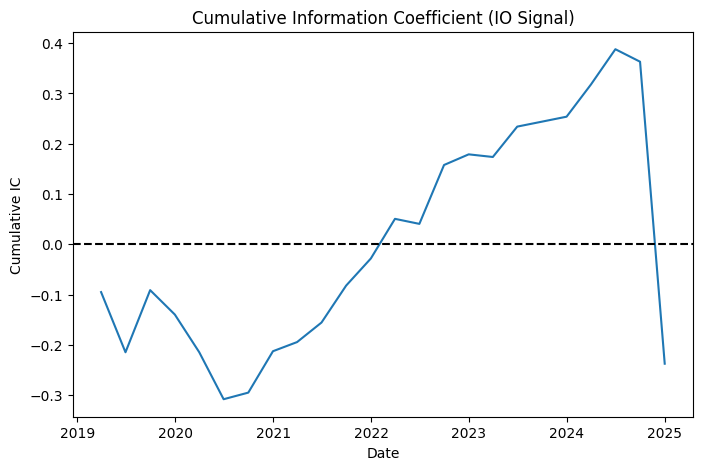

In [39]:
panel_pd["alpha"] = (
    panel_pd
    .groupby("qdate")["io_pct"]
    .transform(lambda x: x.rank(pct=True))  # percentile rank
)

ic_series = (
    panel_pd
    .groupby("qdate")
    .apply(lambda x: x["alpha"].corr(x["ret_fwd"], method="spearman"))
)

cum_ic = ic_series.cumsum()

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(cum_ic.index, cum_ic.values)
plt.title("Cumulative Information Coefficient (IO Signal)")
plt.ylabel("Cumulative IC")
plt.xlabel("Date")
plt.axhline(0, color="black", linestyle="--")
plt.show()

In [40]:
mean_ic = ic_series.mean()
ic_ir = mean_ic / ic_series.std()

print("Mean IC:", round(mean_ic, 4))
print("IC IR:", round(ic_ir, 4))

Mean IC: -0.0099
IC IR: -0.0696
